# 05b_model_testing.ipynb
**DyPriZa – Diagnóstico avanzado y validación**

Incluye:
- Validación cruzada (k=5) de LinearRegression, Ridge y RandomForest (baseline)
- GridSearchCV para **RandomForest** con **imputación** (SimpleImputer) en pipeline
- Evaluación en test de los mejores modelos
- Curva de aprendizaje (RandomForest ajustado)
- Importancia de variables (Gini y Permutation Importance)

__Entradas__: `data/DyPriZa_features.csv`
__Salidas__:
- `data/DyPriZa_cv_results.csv`
- `data/DyPriZa_test_results.csv`
- `data/DyPriZa_rf_feature_importance.csv`
- `data/DyPriZa_permutation_importance.csv`
- `models/DyPriZa_rf_tuned.joblib`
- `data/DyPriZa_predictions_test_05b.csv`


In [1]:
import pandas as pd 
import numpy as np 
from pathlib import Path 
import matplotlib .pyplot as plt 

INPUT_PATH ='data/DyPriZa_features.csv'
Path ('data').mkdir (exist_ok =True )
Path ('models').mkdir (exist_ok =True )

data =pd .read_csv (INPUT_PATH )
data .columns =[str (c ).strip ()for c in data .columns ]
print ('✅ Features cargado:',data .shape )
data .head (3 )


✅ Features cargado: (500, 35)


,is_canceled,adr,arrival_date,lead_time,stay_nights,guests,hotel,country,reserved_room_type,assigned_room_type,...,temporada_baja,temporada_media,dia_semana_Monday,dia_semana_Saturday,dia_semana_Sunday,dia_semana_Thursday,dia_semana_Tuesday,dia_semana_Wednesday,market_segment_Direct,market_segment_OTA
0,1,134.33,2023-01-01,119,10,1,City,DE,B,C,...,True,False,False,False,True,False,False,False,False,False
1,1,94.61,2023-01-05,3,11,4,Resort,UK,C,B,...,True,False,False,False,False,True,False,False,False,False
2,0,57.06,2023-01-06,94,1,2,Resort,ES,C,A,...,True,False,False,False,False,False,False,False,False,False


## 1) Preparación de datos y detección robusta de columnas

In [5]:
lower ={c :c .lower ()for c in data .columns }
dfl =data .rename (columns =lower )

def detect_price_col (df ):
    keys =['precio','price','tarifa','adr','rate','avg_daily_rate','base_price']
    for c in df .columns :
        if any (k in c for k in keys ):
            return c 

    best ,score =None ,-1 
    for c in df .select_dtypes (include =[np .number ]).columns :
        s =pd .to_numeric (df [c ],errors ='coerce')
        sc =(s .notna ().mean ()*1000 )+s .var ()
        if s .max ()>0 and sc >score :
            best ,score =c ,sc 
    return best 

c_precio =detect_price_col (dfl )
c_fecha =next ((c for c in dfl .columns if c in ('fecha','date','ds')),None )
c_prop =next ((c for c in dfl .columns if c in ('propiedad','listing_id','property_id','id_propiedad','idpropiedad')),None )
print ({'precio':c_precio ,'fecha':c_fecha ,'propiedad':c_prop })

y =pd .to_numeric (dfl [c_precio ],errors ='coerce')
X =dfl .drop (columns =[c for c in [c_precio ,c_fecha ,c_prop ]if c ],errors ='ignore').select_dtypes (include =[np .number ])


X =X .replace ([np .inf ,-np .inf ],np .nan ).dropna (axis =1 ,how ='all')
mask =y .notna ()
X ,y =X .loc [mask ],y .loc [mask ]
print ('X shape:',X .shape )


{'precio': 'adr', 'fecha': None, 'propiedad': None}
X shape: (500, 19)


## 2) Validación cruzada (k=5) – Linear, Ridge y RandomForest (baseline)

In [7]:
from sklearn .model_selection import KFold ,cross_validate ,train_test_split ,GridSearchCV ,learning_curve 
from sklearn .pipeline import Pipeline 
from sklearn .preprocessing import StandardScaler 
from sklearn .linear_model import LinearRegression ,Ridge 
from sklearn .ensemble import RandomForestRegressor 
from sklearn .impute import SimpleImputer 
from sklearn .metrics import mean_absolute_error ,mean_squared_error ,r2_score ,make_scorer 

cv =KFold (n_splits =5 ,shuffle =True ,random_state =42 )
num_imp =SimpleImputer (strategy ='median')

models_cv ={
'LinearRegression':Pipeline ([('imputer',num_imp ),('scaler',StandardScaler (with_mean =False )),('model',LinearRegression ())]),
'Ridge':Pipeline ([('imputer',num_imp ),('scaler',StandardScaler (with_mean =False )),('model',Ridge (alpha =1.0 ))]),
'RandomForest':Pipeline ([('imputer',num_imp ),('model',RandomForestRegressor (n_estimators =300 ,random_state =42 ,n_jobs =-1 ))])
}

scoring ={
'MAE':make_scorer (mean_absolute_error ,greater_is_better =False ),
'RMSE':make_scorer (lambda yt ,yp :mean_squared_error (yt ,yp ,squared =False ),greater_is_better =False ),
'R2':'r2'
}

rows =[]
for name ,pipe in models_cv .items ():
    cvres =cross_validate (pipe ,X ,y ,cv =cv ,scoring =scoring ,n_jobs =-1 )
    rows .append ({
    'Modelo':name ,
    'MAE_CV_mean':-cvres ['test_MAE'].mean (),
    'RMSE_CV_mean':-cvres ['test_RMSE'].mean (),
    'R2_CV_mean':cvres ['test_R2'].mean ()
    })

cv_table =pd .DataFrame (rows ).sort_values ('RMSE_CV_mean')
cv_table .to_csv ('data/DyPriZa_cv_results.csv',index =False )
cv_table 


,Modelo,MAE_CV_mean,RMSE_CV_mean,R2_CV_mean
0,LinearRegression,1.978158,2.849058,0.995849
1,Ridge,2.100929,2.943569,0.995571
2,RandomForest,2.795889,4.305446,0.990269


## 3) GridSearchCV – RandomForest con imputación en pipeline

In [8]:
rf_pipe =Pipeline ([
('imputer',SimpleImputer (strategy ='median')),
('model',RandomForestRegressor (random_state =42 ,n_jobs =-1 ))
])
param_grid ={
'model__n_estimators':[200 ,400 ,600 ],
'model__max_depth':[None ,8 ,12 ,16 ],
'model__min_samples_split':[2 ,5 ,10 ],
'model__min_samples_leaf':[1 ,2 ,4 ],
'model__max_features':['sqrt','log2',0.6 ]
}
grid =GridSearchCV (rf_pipe ,param_grid ,cv =3 ,scoring ='neg_root_mean_squared_error',n_jobs =-1 ,verbose =1 )
X_train ,X_test ,y_train ,y_test =train_test_split (X ,y ,test_size =0.2 ,random_state =42 )
grid .fit (X_train ,y_train )
best_rf =grid .best_estimator_ 
best_params =grid .best_params_ 
print ('🏆 Mejores parámetros RF:',best_params )

import joblib 
joblib .dump (best_rf ,'models/DyPriZa_rf_tuned.joblib')


Fitting 3 folds for each of 324 candidates, totalling 972 fits
🏆 Mejores parámetros RF: {'model__max_depth': None, 'model__max_features': 0.6, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 600}


['models/DyPriZa_rf_tuned.joblib']

## 4) Evaluación en test y guardado de predicciones

In [13]:
def metrics (y_true ,y_pred ):
    return (
    mean_absolute_error (y_true ,y_pred ),
    mean_squared_error (y_true ,y_pred ,squared =False ),
    r2_score (y_true ,y_pred )
    )

final_models ={
'LinearRegression':Pipeline ([('imputer',SimpleImputer (strategy ='median')),('scaler',StandardScaler (with_mean =False )),('model',LinearRegression ())]),
'Ridge':Pipeline ([('imputer',SimpleImputer (strategy ='median')),('scaler',StandardScaler (with_mean =False )),('model',Ridge (alpha =1.0 ))]),
'RandomForest_tuned':best_rf 
}

rows =[]
pred_store ={}
for name ,mdl in final_models .items ():
    mdl .fit (X_train ,y_train )
    y_pred =mdl .predict (X_test )
    mae ,rmse ,r2 =metrics (y_test ,y_pred )
    rows .append ({'Modelo':name ,'MAE_test':mae ,'RMSE_test':rmse ,'R2_test':r2 })
    pred_store [name ]=y_pred 

test_table =pd .DataFrame (rows ).sort_values ('RMSE_test')
test_table .to_csv ('data/DyPriZa_test_results.csv',index =False )


best_name =test_table .iloc [0 ]['Modelo']
y_pred_best =pred_store [best_name ]
pred_df =pd .DataFrame ({'precio_real':y_test .values ,'precio_predicho':y_pred_best })
pred_df ['error']=pred_df ['precio_real']-pred_df ['precio_predicho']
pred_df .to_csv ('data/DyPriZa_predictions_test_05b.csv',index =False )
test_table 


C:\Users\nuria\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\nuria\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\nuria\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


,Modelo,MAE_test,RMSE_test,R2_test
0,LinearRegression,1.853839,2.660235,0.996102
1,Ridge,2.019108,2.799311,0.995684
2,RandomForest_tuned,3.206134,4.892204,0.986817


## 5) Curva de aprendizaje – RandomForest (tuned)

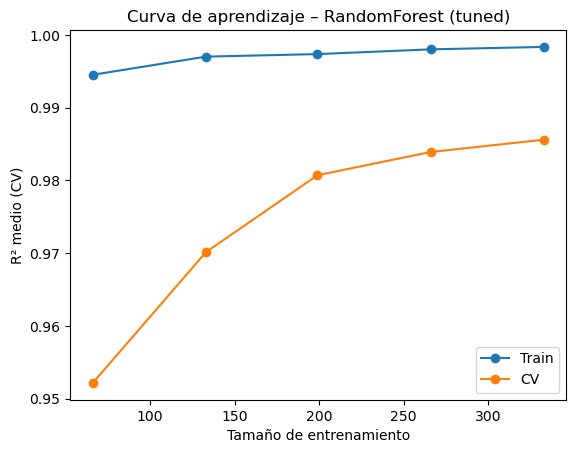

In [15]:
train_sizes ,train_scores ,test_scores =learning_curve (best_rf ,X ,y ,cv =3 ,scoring ='r2',n_jobs =-1 ,train_sizes =np .linspace (0.2 ,1.0 ,5 ))
train_mean =train_scores .mean (axis =1 )
test_mean =test_scores .mean (axis =1 )

plt .figure ()
plt .plot (train_sizes ,train_mean ,marker ='o')
plt .plot (train_sizes ,test_mean ,marker ='o')
plt .xlabel ('Tamaño de entrenamiento')
plt .ylabel ('R² medio (CV)')
plt .title ('Curva de aprendizaje – RandomForest (tuned)')
plt .legend (['Train','CV'])
plt .show ()


## 6) Importancias (Gini y Permutation Importance)

In [19]:

from sklearn .inspection import permutation_importance 
from sklearn .base import clone 
import numpy as np 
import pandas as pd 


best_rf .fit (X_train ,y_train )


rf_inner =best_rf .named_steps ['model']if hasattr (best_rf ,"named_steps")else best_rf 
imp =pd .Series (rf_inner .feature_importances_ ,index =X .columns ).sort_values (ascending =False )
imp_df =imp .reset_index ().rename (columns ={'index':'feature',0 :'importance'})
imp_df .to_csv ('data/DyPriZa_rf_feature_importance.csv',index =False )
print ('✅ Guardado: data/DyPriZa_rf_feature_importance.csv')



est_pi =clone (best_rf )
est_pi .fit (X_train ,y_train )


X_test_np =X_test .to_numpy ()
y_test_np =y_test .to_numpy ()


perm =permutation_importance (
est_pi ,
X_test_np ,
y_test_np ,
n_repeats =5 ,
random_state =42 ,
n_jobs =1 
)

perm_df =pd .DataFrame ({
'feature':X .columns ,
'importance_mean':perm .importances_mean ,
'importance_std':perm .importances_std 
}).sort_values ('importance_mean',ascending =False )

perm_df .to_csv ('data/DyPriZa_permutation_importance.csv',index =False )
print ('✅ Guardado: data/DyPriZa_permutation_importance.csv')

imp_df .head (10 )


✅ Guardado: data/DyPriZa_rf_feature_importance.csv


C:\Users\nuria\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\nuria\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\nuria\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\nuria\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\nuria\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\nuria\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid featur

✅ Guardado: data/DyPriZa_permutation_importance.csv


,feature,importance
0,precio_vs_30d,0.675258
1,precio_vs_7d,0.260333
2,precio_7d_media,0.033341
3,precio_30d_media,0.016287
4,precio_lag_1,0.003224
5,lead_time,0.002006
6,precio_lag_7,0.001681
7,dia,0.001463
8,mes,0.001348
9,stay_nights,0.001032
